In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import pearsonr

In [3]:
df_scada = pd.read_csv("scada_operational_data.csv")
df_insp = pd.read_csv("inspection_history.csv")
df_pipe = pd.read_csv("pipe_static_data.csv")
df_rbi = pd.read_csv("rbi_labels.csv")    
print(f"✓ SCADA cargado: {df_scada.shape}")

✓ SCADA cargado: (13152, 13)


In [4]:
df_scada.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13152 entries, 0 to 13151
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   date                  13152 non-null  object 
 1   line_id               13152 non-null  object 
 2   pressure_bar          13152 non-null  float64
 3   temperature_c         13152 non-null  float64
 4   flow_rate_m3h         13152 non-null  float64
 5   vibration_mm_s        13152 non-null  float64
 6   ambient_temp_c        13152 non-null  float64
 7   h2s_ppm               13152 non-null  float64
 8   arab_heavy_fraction   13152 non-null  float64
 9   moisture_factor       13152 non-null  float64
 10  corrosion_rate_mm_yr  13152 non-null  float64
 11  maintenance_flag      13152 non-null  int64  
 12  anomaly_flag          13152 non-null  int64  
dtypes: float64(9), int64(2), object(2)
memory usage: 1.3+ MB


In [5]:
df_scada.describe().T

,count,mean,std,min,25%,50%,75%,max
pressure_bar,13152.0,14.795433,9.336436,4.000,8.44000,12.8100,17.2425,45.9900
temperature_c,13152.0,145.520491,93.794784,4.600,75.62500,129.9000,193.1250,371.1000
flow_rate_m3h,13152.0,98.938838,89.786541,0.000,31.00000,73.0500,142.0500,379.9000
vibration_mm_s,13152.0,2.337278,1.406206,0.050,1.32800,1.9675,3.0990,6.3730
ambient_temp_c,13152.0,8.201612,6.756062,-5.800,2.10000,7.6000,14.6000,22.3000
h2s_ppm,13152.0,438.676627,541.025968,0.000,33.75000,257.0000,533.0000,2580.0000
arab_heavy_fraction,13152.0,0.250413,0.040438,0.150,0.21700,0.2500,0.2830,0.3800
moisture_factor,13152.0,1.171677,0.234254,1.000,1.00000,1.0000,1.3000,1.7000
corrosion_rate_mm_yr,13152.0,0.224150,0.152736,0.045,0.10235,0.2303,0.3210,0.8568
maintenance_flag,13152.0,0.005246,0.072244,0.000,0.00000,0.0000,0.0000,1.0000


In [6]:
# ── Calidad de datos ──────────────────────────────────────────────
print("="*50)
print("VALORES NULOS POR DATASET")
print("="*50)

for nombre, df in [("SCADA", df_scada), 
                   ("Inspeccion", df_insp),
                   ("Pipe Static", df_pipe), 
                   ("RBI Labels", df_rbi)]:
    nulos = df.isnull().sum()
    nulos = nulos[nulos > 0]
    pct   = (df.isnull().sum() / len(df) * 100).round(2)
    pct   = pct[pct > 0]
    if len(nulos) == 0:
        print(f"\n✓ {nombre}: sin valores nulos ({df.shape})")
    else:
        print(f"\n⚠ {nombre}: {len(nulos)} columnas con nulos")
        for col in nulos.index:
            print(f"   {col}: {nulos[col]} nulos ({pct[col]}%)")

print("\n" + "="*50)
print("TIPOS DE DATOS — SCADA")
print("="*50)
print(df_scada.dtypes)

print("\n" + "="*50)
print("ACTIVOS UNICOS EN CADA DATASET")
print("="*50)
print(f"SCADA     : {sorted(df_scada['line_id'].unique())}")
print(f"Inspeccion: {sorted(df_insp['line_id'].unique())}")
print(f"RBI Labels: {sorted(df_rbi['line_id'].unique())}")
print(f"Pipe Static: {sorted(df_pipe['line_id'].unique())}")

VALORES NULOS POR DATASET

✓ SCADA: sin valores nulos ((13152, 13))

✓ Inspeccion: sin valores nulos ((512, 15))

✓ Pipe Static: sin valores nulos ((12, 29))

✓ RBI Labels: sin valores nulos ((432, 17))

TIPOS DE DATOS — SCADA
date                     object
line_id                  object
pressure_bar            float64
temperature_c           float64
flow_rate_m3h           float64
vibration_mm_s          float64
ambient_temp_c          float64
h2s_ppm                 float64
arab_heavy_fraction     float64
moisture_factor         float64
corrosion_rate_mm_yr    float64
maintenance_flag          int64
anomaly_flag              int64
dtype: object

ACTIVOS UNICOS EN CADA DATASET
SCADA     : ['E-101', 'L-01', 'L-02', 'L-03', 'L-04', 'L-05', 'L-06', 'L-07', 'L-08', 'L-09', 'L-10', 'V-101']
Inspeccion: ['E-101', 'L-01', 'L-02', 'L-03', 'L-04', 'L-05', 'L-06', 'L-07', 'L-08', 'L-09', 'L-10', 'V-101']
RBI Labels: ['E-101', 'L-01', 'L-02', 'L-03', 'L-04', 'L-05', 'L-06', 'L-07', 'L-08', 'L-

In [7]:
# ── Conversion de fechas ──────────────────────────────────────────
df_scada['date'] = pd.to_datetime(df_scada['date'])
df_insp['inspection_date'] = pd.to_datetime(df_insp['inspection_date'])

print("="*50)
print("PERIODO TEMPORAL")
print("="*50)
print(f"SCADA inicio : {df_scada['date'].min().strftime('%Y-%m-%d')}")
print(f"SCADA fin    : {df_scada['date'].max().strftime('%Y-%m-%d')}")
print(f"Dias totales : {(df_scada['date'].max() - df_scada['date'].min()).days}")
print(f"Registros    : {len(df_scada):,} ({len(df_scada)/12:.0f} dias x 12 activos)")

print("\n" + "="*50)
print("REGISTROS POR ACTIVO — SCADA")
print("="*50)
registros = df_scada.groupby('line_id').size().reset_index(name='n_registros')
registros['dias'] = registros['n_registros']
registros['completo'] = registros['n_registros'].apply(
    lambda x: '✓' if x >= 1090 else '⚠'
)
print(registros.to_string(index=False))

print("\n" + "="*50)
print("CAMPANAS DE INSPECCION POR ACTIVO")
print("="*50)
campanas = df_insp.groupby('line_id').agg(
    n_campanas=('campaign_number','max'),
    n_mediciones=('inspection_id','count'),
    primera=('inspection_date','min'),
    ultima=('inspection_date','max'),
    ffs_fail=('fitness_for_service', lambda x: (x=='Fail').sum())
).reset_index()
print(campanas.to_string(index=False))

PERIODO TEMPORAL
SCADA inicio : 2020-01-01
SCADA fin    : 2022-12-31
Dias totales : 1095
Registros    : 13,152 (1096 dias x 12 activos)

REGISTROS POR ACTIVO — SCADA
line_id  n_registros  dias completo
  E-101         1096  1096        ✓
   L-01         1096  1096        ✓
   L-02         1096  1096        ✓
   L-03         1096  1096        ✓
   L-04         1096  1096        ✓
   L-05         1096  1096        ✓
   L-06         1096  1096        ✓
   L-07         1096  1096        ✓
   L-08         1096  1096        ✓
   L-09         1096  1096        ✓
   L-10         1096  1096        ✓
  V-101         1096  1096        ✓

CAMPANAS DE INSPECCION POR ACTIVO
line_id  n_campanas  n_mediciones    primera     ultima  ffs_fail
  E-101           3            56 2016-09-14 2022-01-17         0
   L-01           4            33 2015-03-10 2021-10-05        14
   L-02           4            40 2016-05-20 2022-03-22        31
   L-03           4            39 2015-06-15 2021-07-18        33
 

In [8]:
# ── Estadistica descriptiva por activo ───────────────────────────
print("="*60)
print("ESTADISTICA DESCRIPTIVA — TASA DE CORROSION POR ACTIVO")
print("="*60)

cr_stats = df_scada.groupby('line_id')['corrosion_rate_mm_yr'].agg(
    media='mean',
    mediana='median',
    std='std',
    p5=lambda x: x.quantile(0.05),
    p95=lambda x: x.quantile(0.95),
    maximo='max'
).round(4).reset_index()

# Agregar clasificacion de riesgo desde pipe_static
cr_stats = cr_stats.merge(
    df_pipe[['line_id','initial_risk_category','tmin_mm','nominal_thickness_mm']],
    on='line_id'
)

# Ordenar por media descendente
cr_stats = cr_stats.sort_values('media', ascending=False)

print(cr_stats.to_string(index=False))

print("\n" + "="*60)
print("ACTIVOS QUE SUPERAN UMBRAL CRITICO (CR > 0.35 mm/yr)")
print("="*60)
criticos = cr_stats[cr_stats['media'] > 0.20]
for _, row in criticos.iterrows():
    print(f"  {row['line_id']:6s} | media={row['media']:.4f} | "
          f"max={row['maximo']:.4f} | riesgo={row['initial_risk_category']}")

print("\n" + "="*60)
print("RESUMEN H2S POR ACTIVO")
print("="*60)
h2s_stats = df_scada.groupby('line_id')['h2s_ppm'].agg(
    media='mean',
    maximo='max',
    p95=lambda x: x.quantile(0.95)
).round(1).reset_index().sort_values('media', ascending=False)
print(h2s_stats.to_string(index=False))

ESTADISTICA DESCRIPTIVA — TASA DE CORROSION POR ACTIVO
line_id  media  mediana    std     p5    p95  maximo initial_risk_category  tmin_mm  nominal_thickness_mm
  V-101 0.4418   0.4086 0.1219 0.2934 0.6535  0.6678                  High      8.5                 22.00
   L-10 0.4330   0.3044 0.2039 0.2353 0.8367  0.8568              Critical      2.8                  5.49
   L-03 0.3500   0.3501 0.0103 0.3336 0.3659  0.3793                  High      3.5                  7.11
   L-02 0.2968   0.2836 0.0337 0.2557 0.3388  0.3483                  High      2.8                  5.49
  E-101 0.2847   0.2588 0.0384 0.2405 0.3291  0.3376                  High      5.0                 12.00
   L-01 0.2796   0.2797 0.0088 0.2648 0.2939  0.3089                  High      4.0                  8.18
   L-05 0.1590   0.1512 0.0226 0.1428 0.2232  0.2383                Medium      3.5                  7.11
   L-06 0.1350   0.1291 0.0153 0.1162 0.1540  0.1597                Medium      2.8              

In [9]:
# Ver los puntos FAIL de L-10
print(df_insp[
    (df_insp['line_id'] == 'L-10') & 
    (df_insp['fitness_for_service'] == 'Fail')
][['inspection_date','measurement_point',
   'measured_thickness_mm','tmin_mm',
   'fitness_for_service']].to_string(index=False))

inspection_date measurement_point  measured_thickness_mm  tmin_mm fitness_for_service
     2018-05-14               BDC                   2.68      2.8                Fail
     2018-05-14               45°                   2.78      2.8                Fail
     2018-05-14              135°                   2.54      2.8                Fail
     2018-05-14              315°                   2.62      2.8                Fail
     2020-09-02               TDC                   2.31      2.8                Fail
     2020-09-02               BDC                   2.30      2.8                Fail
     2020-09-02               3OC                   2.41      2.8                Fail
     2020-09-02               9OC                   2.35      2.8                Fail
     2020-09-02               45°                   2.59      2.8                Fail
     2020-09-02              135°                   2.37      2.8                Fail
     2020-09-02              225°                   2.

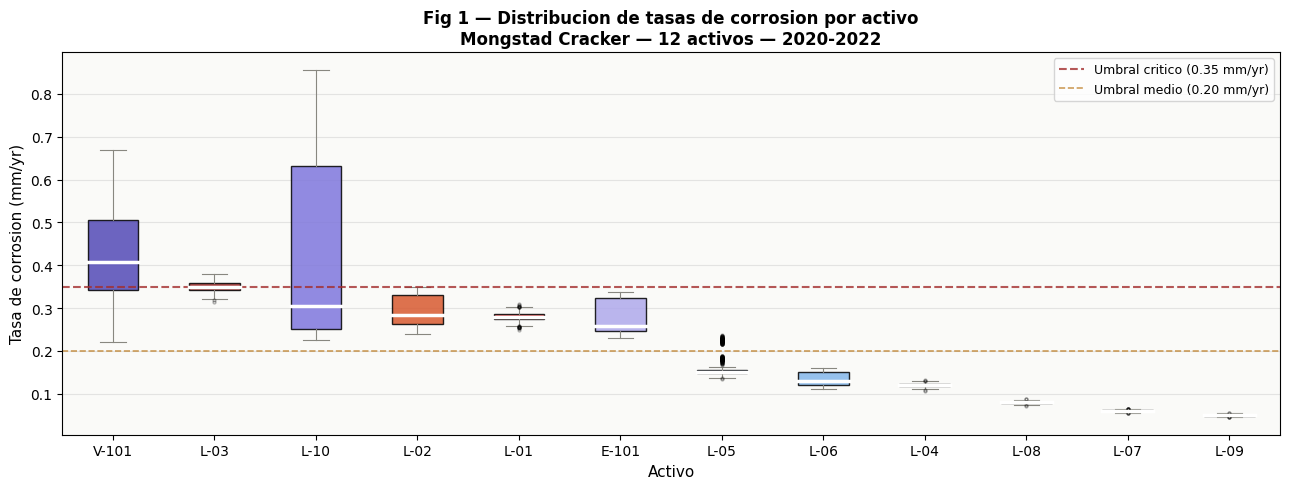

✓ Fig 1 guardada


In [10]:
# ── Fig 1 — Distribucion CR por activo ───────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))

# Orden por mediana descendente
order = df_scada.groupby('line_id')['corrosion_rate_mm_yr']\
        .median().sort_values(ascending=False).index

# Colores por nivel de riesgo
risk_colors = {
    'L-10':'#7F77DD', 'V-101':'#534AB7', 'L-03':'#A32D2D',
    'L-02':'#D85A30', 'E-101':'#AFA9EC', 'L-01':'#E24B4A',
    'L-05':'#378ADD', 'L-06':'#85B7EB', 'L-04':'#185FA5',
    'L-08':'#639922', 'L-07':'#3B6D11', 'L-09':'#97C459'
}

# Datos en orden
data_ordered = [
    df_scada[df_scada.line_id == lid]['corrosion_rate_mm_yr'].values
    for lid in order
]
colors_ordered = [risk_colors[lid] for lid in order]

bp = ax.boxplot(
    data_ordered, labels=order,
    patch_artist=True, notch=False,
    medianprops=dict(color='white', linewidth=2.5),
    whiskerprops=dict(linewidth=0.8, color='#888780'),
    capprops=dict(linewidth=0.8, color='#888780'),
    flierprops=dict(marker='o', markersize=2, alpha=0.3)
)
for patch, color in zip(bp['boxes'], colors_ordered):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)

# Umbrales de referencia
ax.axhline(0.35, color='#A32D2D', lw=1.5, ls='--', alpha=0.8,
           label='Umbral critico (0.35 mm/yr)')
ax.axhline(0.20, color='#BA7517', lw=1.2, ls='--', alpha=0.7,
           label='Umbral medio (0.20 mm/yr)')

ax.set_xlabel('Activo', fontsize=11)
ax.set_ylabel('Tasa de corrosion (mm/yr)', fontsize=11)
ax.set_title('Fig 1 — Distribucion de tasas de corrosion por activo\n'
             'Mongstad Cracker — 12 activos — 2020-2022',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
ax.set_facecolor('#FAFAF8')
fig.patch.set_facecolor('white')

plt.tight_layout()
plt.savefig('fig01_cr_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Fig 1 guardada")

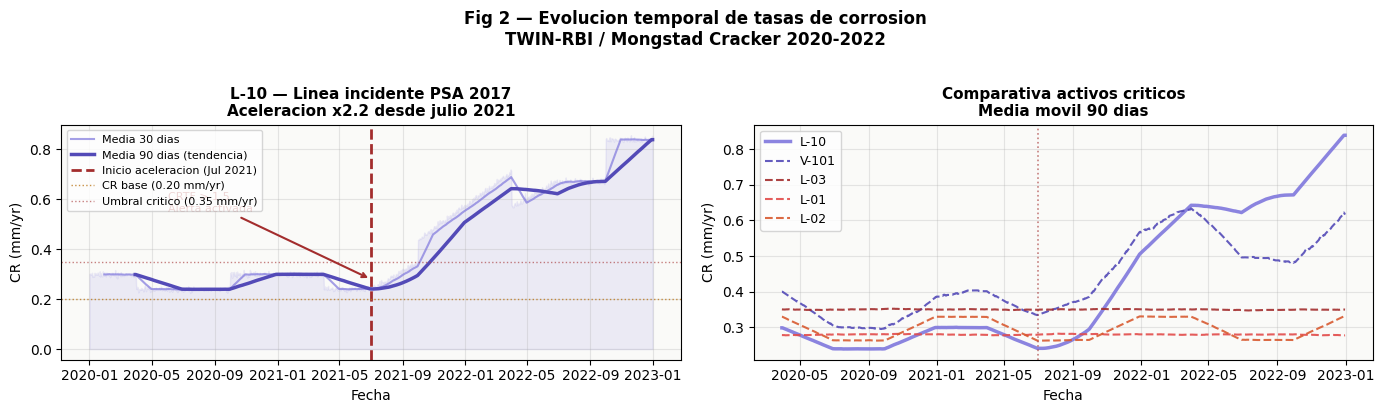

✓ Fig 2 guardada


In [11]:
# ── Fig 2 — Serie temporal L-10: aceleracion confirmada ──────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ── Panel izquierdo: L-10 con aceleracion marcada ────────────────
l10 = df_scada[df_scada.line_id == 'L-10'].set_index('date').sort_index()
cr_raw  = l10['corrosion_rate_mm_yr']
cr_30d  = cr_raw.rolling(30).mean()
cr_90d  = cr_raw.rolling(90).mean()

ax = axes[0]
ax.fill_between(cr_raw.index, cr_raw.values,
                alpha=0.12, color='#7F77DD')
ax.plot(cr_raw.index, cr_30d,
        color='#7F77DD', lw=1.5, alpha=0.7, label='Media 30 dias')
ax.plot(cr_raw.index, cr_90d,
        color='#534AB7', lw=2.5, label='Media 90 dias (tendencia)')
ax.axvline(pd.Timestamp('2021-07-01'),
           color='#A32D2D', lw=2, ls='--',
           label='Inicio aceleracion (Jul 2021)')
ax.axhline(0.20, color='#BA7517', lw=1, ls=':',
           alpha=0.8, label='CR base (0.20 mm/yr)')
ax.axhline(0.35, color='#A32D2D', lw=1, ls=':',
           alpha=0.6, label='Umbral critico (0.35 mm/yr)')

ax.set_title('L-10 — Linea incidente PSA 2017\nAceleracion x2.2 desde julio 2021',
             fontsize=11, fontweight='bold')
ax.set_ylabel('CR (mm/yr)')
ax.set_xlabel('Fecha')
ax.legend(fontsize=8, loc='upper left')
ax.set_facecolor('#FAFAF8')
ax.grid(alpha=0.3)

# Anotacion en el punto de aceleracion
ax.annotate('CRTF > 1.5\nAlerta activada',
            xy=(pd.Timestamp('2021-07-01'), 0.28),
            xytext=(pd.Timestamp('2020-06-01'), 0.55),
            fontsize=8, color='#A32D2D',
            arrowprops=dict(arrowstyle='->', color='#A32D2D', lw=1.5))

# ── Panel derecho: comparativa activos criticos ───────────────────
ax2 = axes[1]
criticos_lines = {
    'L-10':  '#7F77DD',
    'V-101': '#534AB7',
    'L-03':  '#A32D2D',
    'L-01':  '#E24B4A',
    'L-02':  '#D85A30',
}

for lid, color in criticos_lines.items():
    sub = df_scada[df_scada.line_id == lid]\
          .set_index('date').sort_index()['corrosion_rate_mm_yr']\
          .rolling(90).mean()
    lw = 2.5 if lid == 'L-10' else 1.5
    ls = '-'  if lid == 'L-10' else '--'
    ax2.plot(sub.index, sub.values,
             color=color, lw=lw, ls=ls,
             label=lid, alpha=0.9)

ax2.axvline(pd.Timestamp('2021-07-01'),
            color='#A32D2D', lw=1.2, ls=':', alpha=0.6)
ax2.set_title('Comparativa activos criticos\nMedia movil 90 dias',
              fontsize=11, fontweight='bold')
ax2.set_ylabel('CR (mm/yr)')
ax2.set_xlabel('Fecha')
ax2.legend(fontsize=9)
ax2.set_facecolor('#FAFAF8')
ax2.grid(alpha=0.3)

fig.suptitle('Fig 2 — Evolucion temporal de tasas de corrosion\n'
             'TWIN-RBI / Mongstad Cracker 2020-2022',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig02_cr_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Fig 2 guardada")

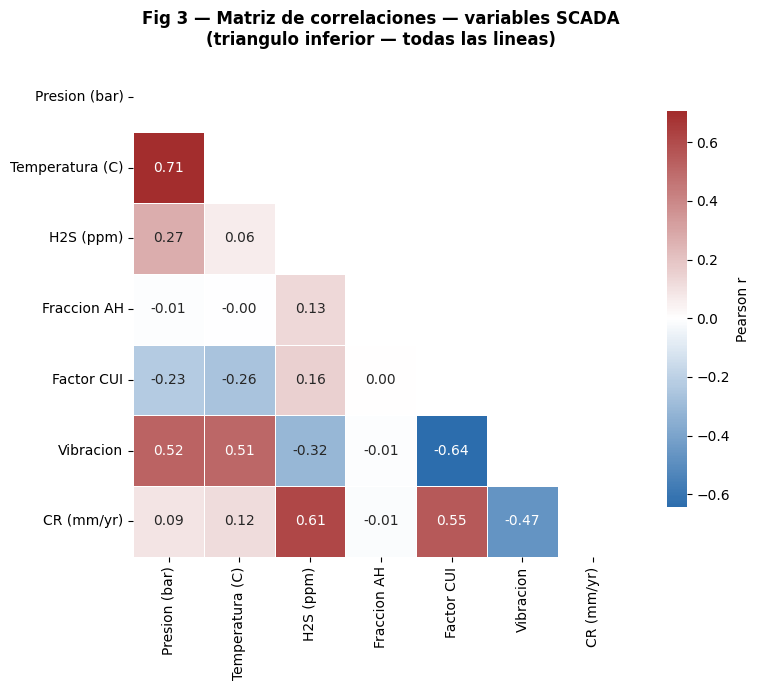

✓ Fig 3 guardada

Correlaciones con CR (mm/yr) — ordenadas:
  ↑ H2S (ppm)                : r = +0.6125
  ↑ Factor CUI               : r = +0.5482
  ↓ Vibracion                : r = -0.4679
  ↑ Temperatura (C)          : r = +0.1204
  ↑ Presion (bar)            : r = +0.0896
  ↓ Fraccion AH              : r = -0.0138


In [12]:
# ── Fig 3 — Matriz de correlaciones ──────────────────────────────
from matplotlib.colors import LinearSegmentedColormap

fig, ax = plt.subplots(figsize=(9, 7))

cols_corr = [
    'pressure_bar', 'temperature_c', 'h2s_ppm',
    'arab_heavy_fraction', 'moisture_factor',
    'vibration_mm_s', 'corrosion_rate_mm_yr'
]
labels_es = [
    'Presion (bar)', 'Temperatura (C)', 'H2S (ppm)',
    'Fraccion AH', 'Factor CUI',
    'Vibracion', 'CR (mm/yr)'
]

corr = df_scada[cols_corr].corr()
corr.index   = labels_es
corr.columns = labels_es

# Colormap personalizado azul-blanco-rojo
cmap = LinearSegmentedColormap.from_list(
    'rbi', ['#185FA5', 'white', '#A32D2D']
)

mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr, annot=True, fmt='.2f',
    cmap=cmap, center=0, mask=mask,
    ax=ax, square=True,
    annot_kws={'size': 10},
    linewidths=0.5,
    cbar_kws={'shrink': 0.8, 'label': 'Pearson r'}
)

ax.set_title('Fig 3 — Matriz de correlaciones — variables SCADA\n'
             '(triangulo inferior — todas las lineas)',
             fontsize=12, fontweight='bold', pad=12)

plt.tight_layout()
plt.savefig('fig03_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Fig 3 guardada")

# Imprimir correlaciones mas importantes con CR
print("\nCorrelaciones con CR (mm/yr) — ordenadas:")
cr_corr = df_scada[cols_corr].corr()['corrosion_rate_mm_yr']\
          .drop('corrosion_rate_mm_yr').sort_values(
              key=abs, ascending=False
          ).round(4)
for var, val in cr_corr.items():
    label = labels_es[cols_corr.index(var)]
    signo = "↑" if val > 0 else "↓"
    print(f"  {signo} {label:25s}: r = {val:+.4f}")

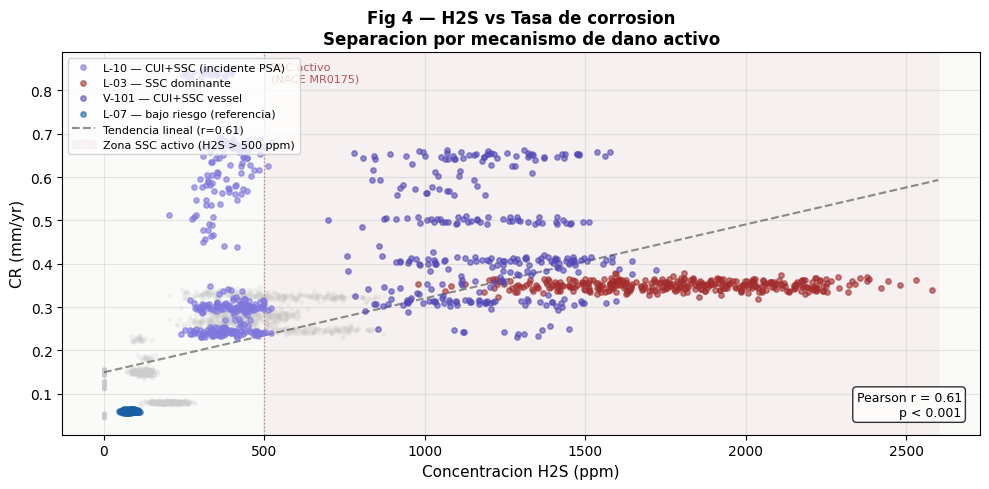

✓ Fig 4 guardada


In [13]:
# ── Fig 4 — H2S vs CR coloreado por mecanismo de dano ────────────
fig, ax = plt.subplots(figsize=(10, 5))

# Clasificar activos por mecanismo dominante
mec_color = {}
for _, row in df_pipe.iterrows():
    if row['ssc_active'] == 1:
        mec_color[row['line_id']] = '#A32D2D'   # SSC activo
    elif row['cui_active'] == 1:
        mec_color[row['line_id']] = '#BA7517'   # CUI dominante
    else:
        mec_color[row['line_id']] = '#185FA5'   # Bajo riesgo

# Sample para no saturar el grafico
sample = df_scada.sample(4000, random_state=42)

# Plotear todos en gris primero
ax.scatter(sample['h2s_ppm'], sample['corrosion_rate_mm_yr'],
           alpha=0.15, s=6, color='#CCCCCC', zorder=1)

# Destacar los activos criticos
highlight = {
    'L-10':  ('#7F77DD', 'L-10 — CUI+SSC (incidente PSA)'),
    'L-03':  ('#A32D2D', 'L-03 — SSC dominante'),
    'V-101': ('#534AB7', 'V-101 — CUI+SSC vessel'),
    'L-07':  ('#185FA5', 'L-07 — bajo riesgo (referencia)'),
}
for lid, (color, label) in highlight.items():
    sub = sample[sample.line_id == lid]
    ax.scatter(sub['h2s_ppm'], sub['corrosion_rate_mm_yr'],
               alpha=0.6, s=15, color=color,
               label=label, zorder=5)

# Linea de tendencia general
from numpy.polynomial import polynomial as P
x_all = sample['h2s_ppm'].values
y_all = sample['corrosion_rate_mm_yr'].values
idx   = np.argsort(x_all)
coef  = np.polyfit(x_all, y_all, 1)
x_line = np.linspace(0, 2600, 100)
ax.plot(x_line, np.polyval(coef, x_line),
        color='#444441', lw=1.5, ls='--',
        alpha=0.6, label=f'Tendencia lineal (r=0.61)')

# Zona SSC activo
ax.axvspan(500, 2600, alpha=0.04, color='#A32D2D',
           label='Zona SSC activo (H2S > 500 ppm)')
ax.axvline(500, color='#A32D2D', lw=1, ls=':', alpha=0.5)
ax.text(520, 0.82, 'SSC activo\n(NACE MR0175)',
        fontsize=8, color='#A32D2D', alpha=0.8)

ax.set_xlabel('Concentracion H2S (ppm)', fontsize=11)
ax.set_ylabel('CR (mm/yr)', fontsize=11)
ax.set_title('Fig 4 — H2S vs Tasa de corrosion\n'
             'Separacion por mecanismo de dano activo',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=8, loc='upper left')
ax.set_facecolor('#FAFAF8')
ax.grid(alpha=0.3)

# Texto con correlacion
ax.text(0.98, 0.05,
        f'Pearson r = 0.61\np < 0.001',
        transform=ax.transAxes,
        fontsize=9, ha='right',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('fig04_h2s_vs_cr.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Fig 4 guardada")

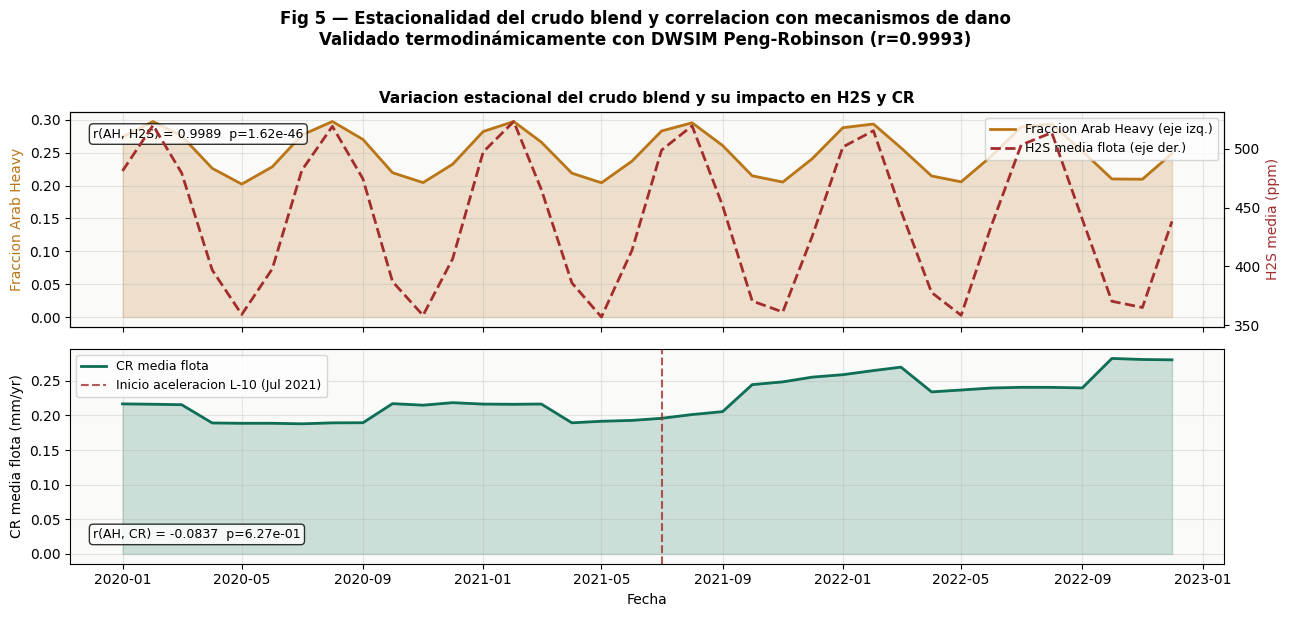

✓ Fig 5 guardada

r(Arab Heavy, H2S) = 0.9989
r(Arab Heavy, CR)  = -0.0837


In [14]:
# ── Fig 5 — Estacionalidad Arab Heavy y su efecto en H2S ─────────
fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)

monthly = df_scada.groupby(
    df_scada['date'].dt.to_period('M')
).agg(
    arab_mean=('arab_heavy_fraction', 'mean'),
    h2s_mean=('h2s_ppm', 'mean'),
    cr_mean=('corrosion_rate_mm_yr', 'mean'),
    moisture_mean=('moisture_factor', 'mean')
).reset_index()
monthly['date_dt'] = monthly['date'].dt.to_timestamp()

# Panel superior: Arab Heavy + H2S
ax1 = axes[0]
ax1b = ax1.twinx()

ax1.fill_between(monthly['date_dt'], monthly['arab_mean'],
                 alpha=0.2, color='#BA7517')
ax1.plot(monthly['date_dt'], monthly['arab_mean'],
         color='#BA7517', lw=2, label='Fraccion Arab Heavy (eje izq.)')

ax1b.plot(monthly['date_dt'], monthly['h2s_mean'],
          color='#A32D2D', lw=2, ls='--',
          label='H2S media flota (eje der.)')

ax1.set_ylabel('Fraccion Arab Heavy', color='#BA7517', fontsize=10)
ax1b.set_ylabel('H2S media (ppm)', color='#A32D2D', fontsize=10)
ax1.set_title('Variacion estacional del crudo blend y su impacto en H2S y CR',
              fontsize=11, fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1b.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, fontsize=9, loc='upper right')
ax1.set_facecolor('#FAFAF8')
ax1.grid(alpha=0.3)

# Calcular correlacion Arab Heavy vs H2S
r_ah_h2s, p_ah_h2s = pearsonr(
    monthly['arab_mean'], monthly['h2s_mean']
)
ax1.text(0.02, 0.88,
         f'r(AH, H2S) = {r_ah_h2s:.4f}  p={p_ah_h2s:.2e}',
         transform=ax1.transAxes, fontsize=9,
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Panel inferior: CR media flota
ax2 = axes[1]
ax2.fill_between(monthly['date_dt'], monthly['cr_mean'],
                 alpha=0.2, color='#0F6E56')
ax2.plot(monthly['date_dt'], monthly['cr_mean'],
         color='#0F6E56', lw=2, label='CR media flota')
ax2.axvline(pd.Timestamp('2021-07-01'),
            color='#A32D2D', lw=1.5, ls='--', alpha=0.8,
            label='Inicio aceleracion L-10 (Jul 2021)')

ax2.set_ylabel('CR media flota (mm/yr)', fontsize=10)
ax2.set_xlabel('Fecha', fontsize=10)
ax2.legend(fontsize=9, loc='upper left')
ax2.set_facecolor('#FAFAF8')
ax2.grid(alpha=0.3)

# Correlacion Arab Heavy vs CR
r_ah_cr, p_ah_cr = pearsonr(
    monthly['arab_mean'], monthly['cr_mean']
)
ax2.text(0.02, 0.12,
         f'r(AH, CR) = {r_ah_cr:.4f}  p={p_ah_cr:.2e}',
         transform=ax2.transAxes, fontsize=9,
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

fig.suptitle('Fig 5 — Estacionalidad del crudo blend y correlacion con mecanismos de dano\n'
             'Validado termodinámicamente con DWSIM Peng-Robinson (r=0.9993)',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig05_seasonality.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Fig 5 guardada")
print(f"\nr(Arab Heavy, H2S) = {r_ah_h2s:.4f}")
print(f"r(Arab Heavy, CR)  = {r_ah_cr:.4f}")

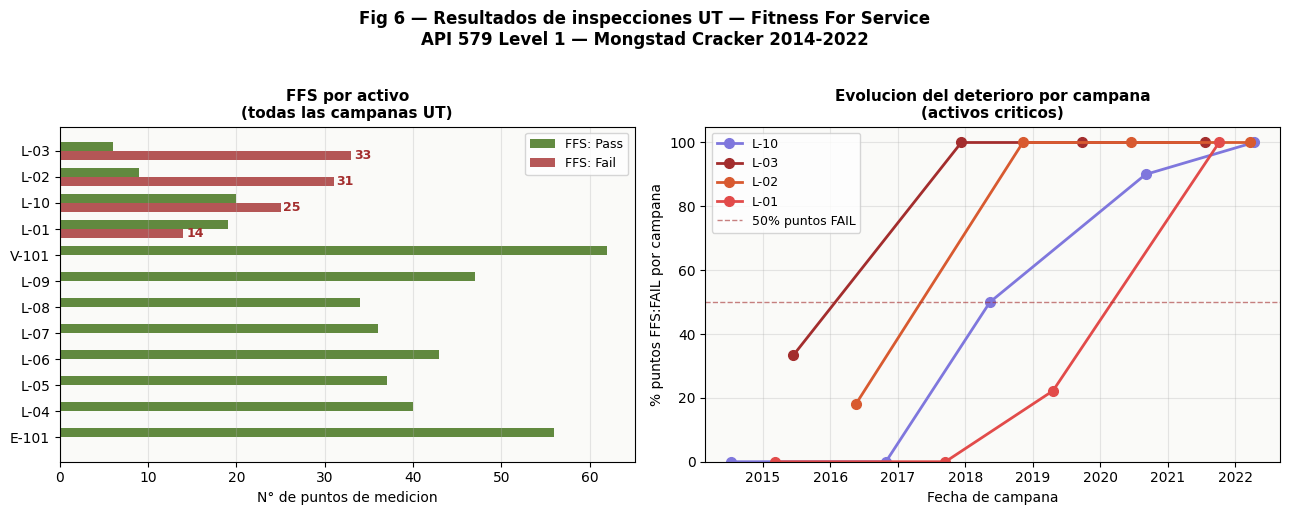

✓ Fig 6 guardada


In [15]:
# ── Fig 6 — FFS Pass/Fail por activo ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Panel izquierdo: barras FFS por activo ────────────────────────
ffs = df_insp.groupby(['line_id','fitness_for_service'])\
      .size().unstack(fill_value=0).reset_index()

if 'Fail' not in ffs.columns: ffs['Fail'] = 0
if 'Pass' not in ffs.columns: ffs['Pass'] = 0

ffs = ffs.sort_values('Fail', ascending=True)

ax = axes[0]
x  = np.arange(len(ffs))
w  = 0.35

bars_pass = ax.barh(x + w/2, ffs['Pass'], w,
                    label='FFS: Pass', color='#3B6D11', alpha=0.8)
bars_fail = ax.barh(x - w/2, ffs['Fail'], w,
                    label='FFS: Fail', color='#A32D2D', alpha=0.8)

ax.set_yticks(x)
ax.set_yticklabels(ffs['line_id'])
ax.set_xlabel('N° de puntos de medicion')
ax.set_title('FFS por activo\n(todas las campanas UT)',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.set_facecolor('#FAFAF8')
ax.grid(axis='x', alpha=0.3)

for bar in bars_fail:
    if bar.get_width() > 0:
        ax.text(bar.get_width() + 0.3,
                bar.get_y() + bar.get_height()/2,
                str(int(bar.get_width())),
                va='center', fontsize=9,
                color='#A32D2D', fontweight='bold')

# ── Panel derecho: evolucion FFS por campana ──────────────────────
ax2 = axes[1]

criticos_ffs = ['L-10', 'L-03', 'L-02', 'L-01']
colores_ffs  = ['#7F77DD', '#A32D2D', '#D85A30', '#E24B4A']

for lid, color in zip(criticos_ffs, colores_ffs):
    sub = df_insp[df_insp.line_id == lid].copy()
    
    # Calcular % FAIL y fecha media por campana — version corregida
    camp_stats = sub.groupby('campaign_number').agg(
        fail_pct=('fitness_for_service',
                  lambda x: (x == 'Fail').sum() / len(x) * 100),
        fecha_media=('inspection_date', 'mean')
    ).reset_index()
    
    ax2.plot(camp_stats['fecha_media'],
             camp_stats['fail_pct'],
             'o-', color=color, lw=2, ms=7,
             label=f'{lid}')

ax2.axhline(50, color='#A32D2D', lw=1, ls='--',
            alpha=0.6, label='50% puntos FAIL')
ax2.set_xlabel('Fecha de campana')
ax2.set_ylabel('% puntos FFS:FAIL por campana')
ax2.set_title('Evolucion del deterioro por campana\n(activos criticos)',
              fontsize=11, fontweight='bold')
ax2.legend(fontsize=9)
ax2.set_facecolor('#FAFAF8')
ax2.grid(alpha=0.3)
ax2.set_ylim(0, 105)

fig.suptitle('Fig 6 — Resultados de inspecciones UT — Fitness For Service\n'
             'API 579 Level 1 — Mongstad Cracker 2014-2022',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig06_ffs_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Fig 6 guardada")

In [16]:
# ── Feature Engineering ──────────────────────────────────────────
df_scada = df_scada.sort_values(['line_id','date']).reset_index(drop=True)

features_list = []

for lid in df_scada['line_id'].unique():
    sub = df_scada[df_scada.line_id == lid].copy().reset_index(drop=True)
    st  = df_pipe[df_pipe.line_id == lid].iloc[0]
    
    nom  = st['nominal_thickness_mm']
    tmin = st['tmin_mm']
    inst = st['install_year']
    
    # CR base — primeros 90 dias
    cr_base = sub['corrosion_rate_mm_yr'].iloc[:90].mean()
    cr_base = max(cr_base, 0.001)
    
    # CRTF — factor de aceleracion
    sub['CRTF'] = sub['corrosion_rate_mm_yr']\
                  .rolling(90, min_periods=30).mean() / cr_base
    
    # CCL — perdida acumulada
    sub['CCL'] = (sub['corrosion_rate_mm_yr'] / 365).cumsum()
    
    # t_est — espesor estimado
    sub['t_est'] = (nom - sub['CCL']).clip(lower=0.1)
    
    # RLY — vida remanente
    cr_roll = sub['corrosion_rate_mm_yr']\
              .rolling(30, min_periods=10).mean().clip(lower=0.001)
    sub['RLY'] = ((sub['t_est'] - tmin) / cr_roll).clip(0, 99)
    
    # PTR — presion / espesor
    sub['PTR'] = sub['pressure_bar'] / sub['t_est']
    
    # HSI — severidad H2S
    sub['HSI'] = (sub['h2s_ppm'] * sub['temperature_c']) / 1000
    
    # CUI score
    sub['CUI_score'] = sub['moisture_factor'] * \
                       sub['temperature_c'].between(60, 175).astype(float)
    
    # SAF — stress amplification factor
    D = st['nominal_diameter_in'] * 25.4 + 2 * nom  # OD en mm
    d_nom = D - 2 * nom
    sub['d_est'] = D - 2 * sub['t_est']
    I_nom = np.pi * (D**4 - d_nom**4) / 64
    sub['I_est'] = np.pi * (D**4 - sub['d_est']**4) / 64
    sub['SAF'] = (I_nom / sub['I_est'].clip(lower=1e-6)).clip(1.0, 10.0)
    
    sub['line_id_feat'] = lid
    features_list.append(sub)

df_feat = pd.concat(features_list, ignore_index=True)

print("="*55)
print("FEATURES CALCULADOS")
print("="*55)
print(f"Shape: {df_feat.shape}")
print(f"\nNuevos features: CRTF, CCL, t_est, RLY, PTR, HSI, CUI_score, SAF")

print("\n" + "="*55)
print("RESUMEN FEATURES CRITICOS — DIC 2022")
print("="*55)
dic22 = df_feat[df_feat['date'] == df_feat['date'].max()]
summary = dic22.groupby('line_id_feat')[
    ['CRTF','t_est','RLY','HSI','SAF']
].mean().round(3).sort_values('CRTF', ascending=False)
print(summary.to_string())

FEATURES CALCULADOS
Shape: (13152, 24)

Nuevos features: CRTF, CCL, t_est, RLY, PTR, HSI, CUI_score, SAF

RESUMEN FEATURES CRITICOS — DIC 2022
               CRTF   t_est     RLY      HSI    SAF
line_id_feat                                       
L-10          2.811   4.190   1.657   46.192  1.252
V-101         1.542  20.673  19.755   69.660  1.061
L-05          1.133   6.633  19.238   20.857  1.063
E-101         1.004  11.145  18.989   57.395  1.072
L-09          1.004   6.960  69.598    0.000  1.019
L-02          1.003   4.599   5.430   70.885  1.157
L-08          1.003   5.780  34.663   11.186  1.035
L-07          1.002   5.840  47.041    7.911  1.026
L-04          1.000   5.660  22.294    0.000  1.053
L-01          0.998   7.340  11.998  147.412  1.102
L-03          0.998   6.059   7.294  439.351  1.151
L-06          0.996   5.085  15.290    0.000  1.065


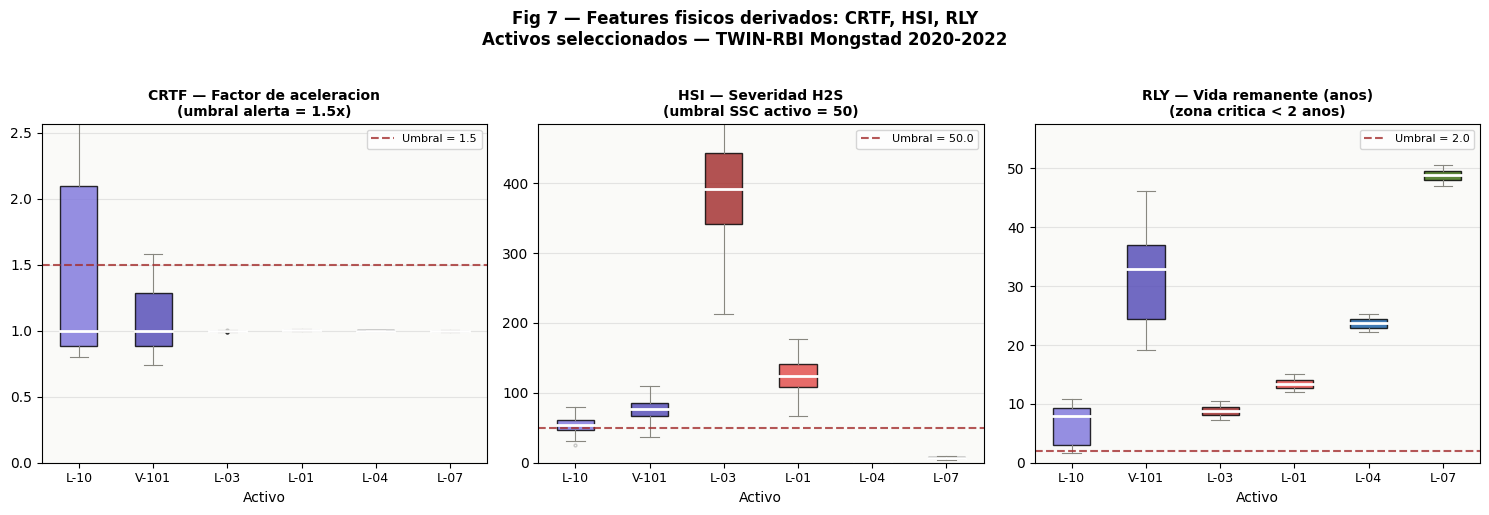

✓ Fig 7 guardada


In [17]:
# ── Fig 7 — Features fisicos: CRTF, HSI, RLY ────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

activos_plot = ['L-10','V-101','L-03','L-01','L-04','L-07']
colores_plot = {
    'L-10':'#7F77DD','V-101':'#534AB7','L-03':'#A32D2D',
    'L-01':'#E24B4A','L-04':'#185FA5','L-07':'#3B6D11'
}

configs = [
    ('CRTF',    'CRTF — Factor de aceleracion\n(umbral alerta = 1.5x)', 1.5,  '#A32D2D'),
    ('HSI',     'HSI — Severidad H2S\n(umbral SSC activo = 50)',        50.0, '#A32D2D'),
    ('RLY',     'RLY — Vida remanente (anos)\n(zona critica < 2 anos)', 2.0,  '#A32D2D'),
]

for ax, (feat, title, threshold, tcolor) in zip(axes, configs):
    data_box    = []
    labels_box  = []
    colors_box  = []

    for lid in activos_plot:
        vals = df_feat[df_feat.line_id_feat == lid][feat].dropna().values
        data_box.append(vals)
        labels_box.append(lid)
        colors_box.append(colores_plot[lid])

    bp = ax.boxplot(
        data_box, labels=labels_box,
        patch_artist=True,
        medianprops=dict(color='white', lw=2),
        whiskerprops=dict(color='#888780', lw=0.8),
        capprops=dict(color='#888780', lw=0.8),
        flierprops=dict(marker='o', ms=2, alpha=0.2)
    )
    for patch, color in zip(bp['boxes'], colors_box):
        patch.set_facecolor(color)
        patch.set_alpha(0.82)

    ax.axhline(threshold, color=tcolor, lw=1.5,
               ls='--', alpha=0.8,
               label=f'Umbral = {threshold}')

    # Limitar eje Y para mejor visualizacion
    p98 = df_feat[
        df_feat.line_id_feat.isin(activos_plot)
    ][feat].quantile(0.98)
    ax.set_ylim(bottom=0, top=min(p98 * 1.15, p98 + 10))

    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel('Activo')
    ax.legend(fontsize=8)
    ax.set_facecolor('#FAFAF8')
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='x', labelsize=9)

fig.suptitle('Fig 7 — Features fisicos derivados: CRTF, HSI, RLY\n'
             'Activos seleccionados — TWIN-RBI Mongstad 2020-2022',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig07_engineered_features.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Fig 7 guardada")

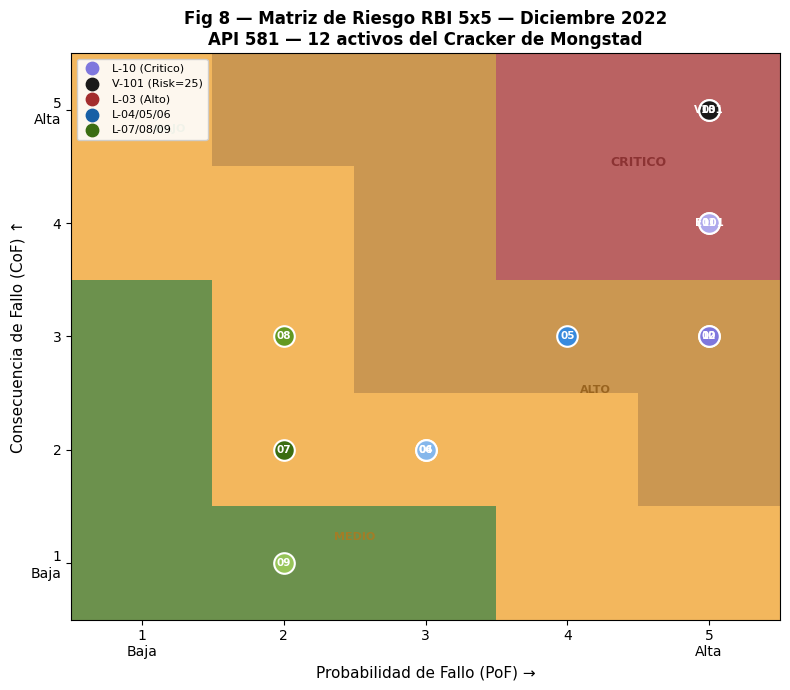

✓ Fig 8 guardada


In [18]:
# ── Fig 8 — Matriz RBI 5x5 estado diciembre 2022 ─────────────────
from matplotlib.colors import LinearSegmentedColormap

fig, ax = plt.subplots(figsize=(8, 7))

# CoF por activo (estatico)
cof_map = {
    'L-01':4,'L-02':3,'L-03':5,'L-04':2,'L-05':3,
    'L-06':2,'L-07':2,'L-08':3,'L-09':1,
    'L-10':3,'V-101':5,'E-101':4
}

# Estado diciembre 2022
last_date = df_rbi['date'].max()
last_rbi  = df_rbi[df_rbi['date'] == last_date].copy()
last_rbi['cof'] = last_rbi['line_id'].map(cof_map)

# Construir grid de colores
matrix = np.zeros((5, 5))
for r in range(5):
    for c in range(5):
        score = (r+1) * (c+1)
        if score >= 16:   matrix[4-r, c] = 4
        elif score >= 9:  matrix[4-r, c] = 3
        elif score >= 4:  matrix[4-r, c] = 2
        else:             matrix[4-r, c] = 1

cmap_rbi = LinearSegmentedColormap.from_list(
    'rbi4', ['#3B6D11','#EF9F27','#BA7517','#A32D2D'], N=4
)
ax.imshow(matrix, cmap=cmap_rbi, aspect='auto',
          vmin=1, vmax=4,
          extent=[0.5, 5.5, 0.5, 5.5], alpha=0.75)

# Plotear activos
for _, row in last_rbi.iterrows():
    pof = int(row['pof_category'])
    cof = cof_map.get(row['line_id'], 3)
    color = {
        'L-10':'#7F77DD','V-101':'#1A1A1A','L-03':'#A32D2D',
        'L-01':'#E24B4A','L-02':'#D85A30','E-101':'#AFA9EC',
        'L-05':'#378ADD','L-04':'#185FA5','L-06':'#85B7EB',
        'L-08':'#639922','L-07':'#3B6D11','L-09':'#97C459'
    }.get(row['line_id'], '#888780')

    ax.scatter(pof, cof, s=220, color=color,
               zorder=5, edgecolors='white', linewidths=1.5)
    label = row['line_id'].replace('L-','').replace('V-','V').replace('E-','E')
    ax.annotate(label, (pof, cof),
                fontsize=7.5, ha='center', va='center',
                color='white', fontweight='bold', zorder=6)

# Etiquetas de zonas
zone_labels = [
    (1.2, 4.8, 'BAJO',    '#3B6D11', 8),
    (2.5, 1.2, 'MEDIO',   '#BA7517', 8),
    (4.2, 2.5, 'ALTO',    '#854F0B', 8),
    (4.5, 4.5, 'CRITICO', '#791F1F', 9),
]
for x, y, txt, col, sz in zone_labels:
    ax.text(x, y, txt, fontsize=sz, color=col,
            fontweight='bold', alpha=0.7, ha='center')

ax.set_xlabel('Probabilidad de Fallo (PoF) →', fontsize=11)
ax.set_ylabel('Consecuencia de Fallo (CoF) ↑', fontsize=11)
ax.set_xticks([1,2,3,4,5])
ax.set_yticks([1,2,3,4,5])
ax.set_xticklabels(['1\nBaja','2','3','4','5\nAlta'])
ax.set_yticklabels(['1\nBaja','2','3','4','5\nAlta'])
ax.set_title('Fig 8 — Matriz de Riesgo RBI 5x5 — Diciembre 2022\n'
             'API 581 — 12 activos del Cracker de Mongstad',
             fontsize=12, fontweight='bold')

# Leyenda
legend_items = [
    plt.scatter([],[],s=80,color='#7F77DD',label='L-10 (Critico)'),
    plt.scatter([],[],s=80,color='#1A1A1A',label='V-101 (Risk=25)'),
    plt.scatter([],[],s=80,color='#A32D2D',label='L-03 (Alto)'),
    plt.scatter([],[],s=80,color='#185FA5',label='L-04/05/06'),
    plt.scatter([],[],s=80,color='#3B6D11',label='L-07/08/09'),
]
ax.legend(handles=legend_items, fontsize=8,
          loc='upper left', framealpha=0.9)
ax.grid(False)

plt.tight_layout()
plt.savefig('fig08_rbi_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Fig 8 guardada")

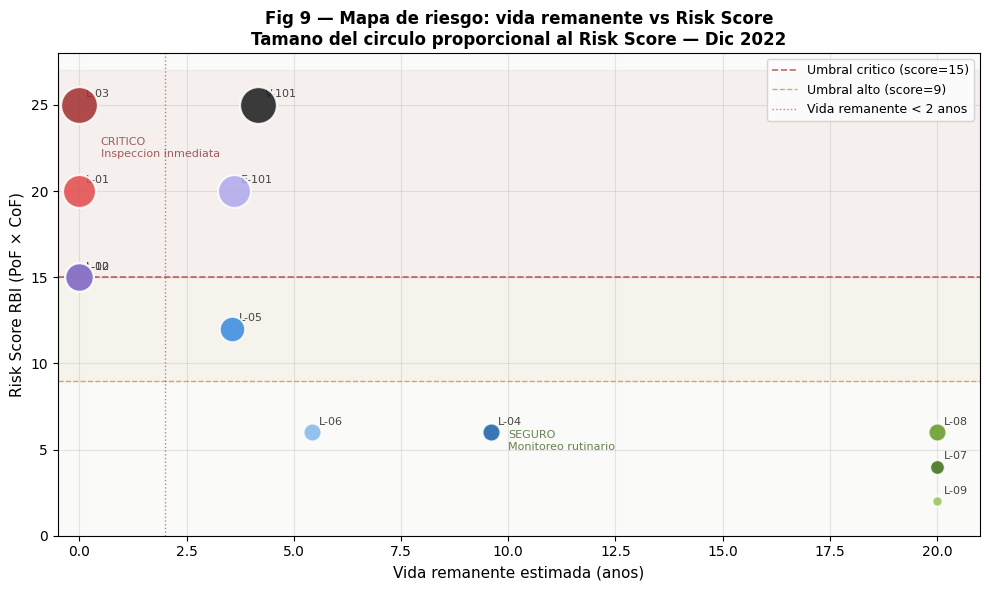

✓ Fig 9 guardada


In [19]:
# ── Fig 9 — Bubble chart: vida remanente vs Risk Score ───────────
fig, ax = plt.subplots(figsize=(10, 6))

# Estado diciembre 2022
last_rbi2 = df_rbi[df_rbi['date'] == last_date].copy()
last_rbi2['cof'] = last_rbi2['line_id'].map(cof_map)
last_rbi2['risk_score'] = last_rbi2['pof_category'] * last_rbi2['cof']
last_rbi2['rly'] = last_rbi2['remaining_life_yr'].clip(0, 20)

color_map_bubble = {
    'L-01':'#E24B4A','L-02':'#D85A30','L-03':'#A32D2D',
    'L-04':'#185FA5','L-05':'#378ADD','L-06':'#85B7EB',
    'L-07':'#3B6D11','L-08':'#639922','L-09':'#97C459',
    'L-10':'#7F77DD','V-101':'#1A1A1A','E-101':'#AFA9EC'
}

for _, row in last_rbi2.iterrows():
    color = color_map_bubble.get(row['line_id'], '#888780')
    size  = row['risk_score'] * 28
    ax.scatter(row['rly'], row['risk_score'],
               s=size, color=color, alpha=0.85,
               edgecolors='white', linewidths=1.5,
               zorder=5)
    ax.annotate(
        row['line_id'],
        (row['rly'], row['risk_score']),
        fontsize=8, ha='left', va='bottom',
        xytext=(5, 4), textcoords='offset points',
        color='#444441'
    )

# Lineas de umbral
ax.axhline(15, color='#A32D2D', lw=1.2, ls='--',
           alpha=0.7, label='Umbral critico (score=15)')
ax.axhline(9,  color='#BA7517', lw=1.0, ls='--',
           alpha=0.6, label='Umbral alto (score=9)')
ax.axvline(2,  color='#A32D2D', lw=1.0, ls=':',
           alpha=0.6, label='Vida remanente < 2 anos')

# Zonas de fondo
ax.axhspan(15, 27, alpha=0.05, color='#A32D2D')
ax.axhspan(9, 15,  alpha=0.05, color='#BA7517')

ax.set_xlabel('Vida remanente estimada (anos)', fontsize=11)
ax.set_ylabel('Risk Score RBI (PoF × CoF)', fontsize=11)
ax.set_title('Fig 9 — Mapa de riesgo: vida remanente vs Risk Score\n'
             'Tamano del circulo proporcional al Risk Score — Dic 2022',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='upper right')
ax.set_facecolor('#FAFAF8')
ax.grid(alpha=0.3)
ax.set_xlim(-0.5, 21)
ax.set_ylim(0, 28)

# Etiquetas de cuadrantes
ax.text(0.5,  22, 'CRITICO\nInspeccion inmediata',
        fontsize=8, color='#791F1F', alpha=0.7)
ax.text(10,   5,  'SEGURO\nMonitoreo rutinario',
        fontsize=8, color='#27500A', alpha=0.7)

plt.tight_layout()
plt.savefig('fig09_risk_bubble.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Fig 9 guardada")

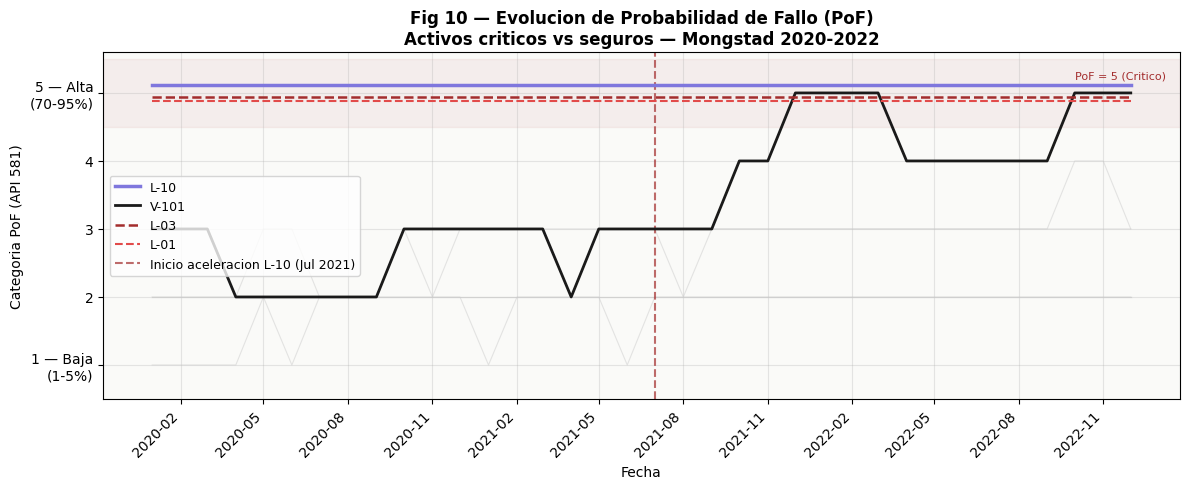

✓ Fig 10 guardada


In [20]:
# ── Fig 10 — Evolucion PoF (version final con offset) ────────────
fig, ax = plt.subplots(figsize=(12, 5))

df_rbi['date_dt'] = pd.to_datetime(df_rbi['date'] + '-01')

# Offset vertical para separar lineas solapadas en PoF=5
offsets = {
    'L-10':  0.12,
    'V-101': 0.00,
    'L-03': -0.06,
    'L-01': -0.12,
}

highlight_pof = {
    'L-10':  ('#7F77DD', 2.5, '-'),
    'V-101': ('#1A1A1A', 2.0, '-'),
    'L-03':  ('#A32D2D', 1.8, '--'),
    'L-01':  ('#E24B4A', 1.5, '--'),
}
background_pof = ['L-07','L-08','L-09','L-04','L-06']

for lid in background_pof:
    sub = df_rbi[df_rbi.line_id == lid].sort_values('date_dt')
    ax.plot(sub['date_dt'], sub['pof_category'],
            color='#CCCCCC', lw=0.8, alpha=0.5)

for lid, (color, lw, ls) in highlight_pof.items():
    sub = df_rbi[df_rbi.line_id == lid].sort_values('date_dt')
    offset = offsets.get(lid, 0)
    ax.plot(sub['date_dt'],
            sub['pof_category'] + offset,
            color=color, lw=lw, ls=ls,
            label=lid, zorder=5)

ax.axvline(pd.Timestamp('2021-07-01'),
           color='#A32D2D', lw=1.5, ls='--', alpha=0.7,
           label='Inicio aceleracion L-10 (Jul 2021)')

ax.axhspan(4.5, 5.5, alpha=0.06, color='#A32D2D')
ax.text(pd.Timestamp('2022-10-01'), 5.25,
        'PoF = 5 (Critico)', fontsize=8,
        color='#A32D2D', va='center')

ax.set_yticks([1,2,3,4,5])
ax.set_yticklabels(['1 — Baja\n(1-5%)','2','3','4','5 — Alta\n(70-95%)'])
ax.set_ylabel('Categoria PoF (API 581)', fontsize=10)
ax.set_xlabel('Fecha', fontsize=10)
ax.set_title('Fig 10 — Evolucion de Probabilidad de Fallo (PoF)\n'
             'Activos criticos vs seguros — Mongstad 2020-2022',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='center left')
ax.set_facecolor('#FAFAF8')
ax.grid(alpha=0.3)
ax.set_ylim(0.5, 5.6)

import matplotlib.dates as mdates
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig('fig10_pof_evolution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Fig 10 guardada")

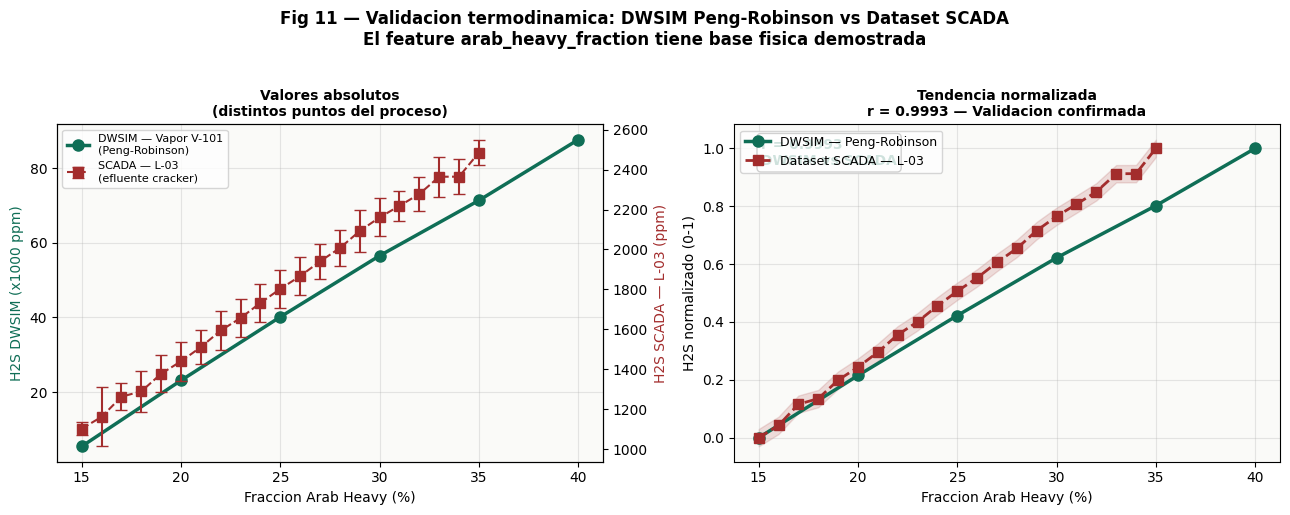

✓ Fig 11 guardada — r = 0.9993


In [21]:
# ── Fig 11 — Validacion DWSIM vs SCADA ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Datos DWSIM del barrido que corrimos
dwsim_data = {
    'arab_heavy_fraction': [0.15, 0.20, 0.25, 0.30, 0.35, 0.40],
    'h2s_ppm_dwsim':       [5491, 23156, 40161, 56546, 71352, 87612]
}
df_dwsim = pd.DataFrame(dwsim_data)

# Normalizar DWSIM
df_dwsim['h2s_norm'] = (
    (df_dwsim['h2s_ppm_dwsim'] - df_dwsim['h2s_ppm_dwsim'].min()) /
    (df_dwsim['h2s_ppm_dwsim'].max() - df_dwsim['h2s_ppm_dwsim'].min())
)

# Datos SCADA — agrupar L-03 por arab_bin
df_l03 = df_scada[df_scada['line_id'] == 'L-03'].copy()
df_l03['arab_bin'] = df_l03['arab_heavy_fraction'].round(2)
df_grp = df_l03.groupby('arab_bin').agg(
    h2s_mean=('h2s_ppm','mean'),
    h2s_std=('h2s_ppm','std'),
    n=('h2s_ppm','count')
).reset_index()
df_grp_filt = df_grp[
    (df_grp['arab_bin'] >= 0.15) &
    (df_grp['arab_bin'] <= 0.40)
].copy()
df_grp_filt['h2s_norm'] = (
    (df_grp_filt['h2s_mean'] - df_grp_filt['h2s_mean'].min()) /
    (df_grp_filt['h2s_mean'].max() - df_grp_filt['h2s_mean'].min())
)

# Correlacion
from scipy.interpolate import interp1d
f_dw = interp1d(df_dwsim['arab_heavy_fraction'],
                df_dwsim['h2s_norm'], kind='linear',
                fill_value='extrapolate')
dwsim_interp = f_dw(df_grp_filt['arab_bin'])
r_val, _ = pearsonr(df_grp_filt['h2s_norm'], dwsim_interp)

# ── Panel izquierdo: valores absolutos con doble eje ─────────────
ax1  = axes[0]
ax1b = ax1.twinx()

ax1.plot(df_dwsim['arab_heavy_fraction']*100,
         df_dwsim['h2s_ppm_dwsim']/1000,
         'o-', color='#0F6E56', lw=2.5, ms=8,
         label='DWSIM — Vapor V-101\n(Peng-Robinson)')
ax1b.errorbar(df_grp_filt['arab_bin']*100,
              df_grp_filt['h2s_mean'],
              yerr=df_grp_filt['h2s_std'],
              fmt='s--', color='#A32D2D', ms=7,
              capsize=4, lw=1.5,
              label='SCADA — L-03\n(efluente cracker)')

ax1.set_xlabel('Fraccion Arab Heavy (%)', fontsize=10)
ax1.set_ylabel('H2S DWSIM (x1000 ppm)', color='#0F6E56', fontsize=10)
ax1b.set_ylabel('H2S SCADA — L-03 (ppm)', color='#A32D2D', fontsize=10)
ax1.set_title('Valores absolutos\n(distintos puntos del proceso)',
              fontsize=10, fontweight='bold')
lines1,lab1 = ax1.get_legend_handles_labels()
lines2,lab2 = ax1b.get_legend_handles_labels()
ax1.legend(lines1+lines2, lab1+lab2, fontsize=8, loc='upper left')
ax1.set_facecolor('#FAFAF8')
ax1.grid(alpha=0.3)

# ── Panel derecho: tendencias normalizadas ────────────────────────
ax2 = axes[1]
ax2.plot(df_dwsim['arab_heavy_fraction']*100,
         df_dwsim['h2s_norm'],
         'o-', color='#0F6E56', lw=2.5, ms=8,
         label='DWSIM — Peng-Robinson')
ax2.plot(df_grp_filt['arab_bin']*100,
         df_grp_filt['h2s_norm'],
         's--', color='#A32D2D', lw=2, ms=7,
         label='Dataset SCADA — L-03')
ax2.fill_between(df_grp_filt['arab_bin']*100,
                 df_grp_filt['h2s_norm'] - 0.03,
                 df_grp_filt['h2s_norm'] + 0.03,
                 alpha=0.15, color='#A32D2D')

ax2.set_xlabel('Fraccion Arab Heavy (%)', fontsize=10)
ax2.set_ylabel('H2S normalizado (0-1)', fontsize=10)
ax2.set_title(f'Tendencia normalizada\nr = {r_val:.4f} — Validacion confirmada',
              fontsize=10, fontweight='bold')
ax2.legend(fontsize=9)
ax2.set_facecolor('#FAFAF8')
ax2.grid(alpha=0.3)

ax2.text(0.05, 0.88,
         f'r = {r_val:.4f}\nDWSIM vs SCADA',
         transform=ax2.transAxes, fontsize=10,
         color='#0F6E56', fontweight='bold',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

fig.suptitle('Fig 11 — Validacion termodinamica: DWSIM Peng-Robinson vs Dataset SCADA\n'
             'El feature arab_heavy_fraction tiene base fisica demostrada',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig11_dwsim_validation.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Fig 11 guardada — r = {r_val:.4f}")

In [22]:
# ── Resumen ejecutivo del EDA ─────────────────────────────────────
print("="*60)
print("RESUMEN EJECUTIVO DEL EDA — TWIN-RBI / MONGSTAD")
print("="*60)

print("\n📊 DATASETS:")
print(f"  SCADA     : {df_scada.shape[0]:,} registros | "
      f"{df_scada['line_id'].nunique()} activos | "
      f"{df_scada['date'].min().date()} → {df_scada['date'].max().date()}")
print(f"  Inspeccion: {df_insp.shape[0]:,} puntos UT | "
      f"{df_insp['fitness_for_service'].value_counts()['Fail']} FFS:FAIL")
print(f"  Features  : {df_feat.shape[1]} columnas "
      f"(8 features fisicos derivados)")
print(f"  Valores nulos: 0 en los 4 datasets ✓")

print("\n🔴 HALLAZGOS CRITICOS:")

# 1. Aceleracion L-10
l10_base = df_feat[
    (df_feat.line_id_feat=='L-10') &
    (df_feat['date'] < '2021-07-01')
]['corrosion_rate_mm_yr'].mean()
l10_final = df_feat[
    (df_feat.line_id_feat=='L-10') &
    (df_feat['date'] >= '2022-01-01')
]['corrosion_rate_mm_yr'].mean()
factor = l10_final / l10_base

print(f"\n  1. L-10 — Aceleracion confirmada:")
print(f"     CR antes jul-2021 : {l10_base:.4f} mm/yr")
print(f"     CR desde ene-2022 : {l10_final:.4f} mm/yr")
print(f"     Factor aceleracion: {factor:.2f}x ← CRTF = {factor:.2f}")

# 2. Espesor estimado L-10
t_nom_l10  = df_pipe[df_pipe.line_id=='L-10']['nominal_thickness_mm'].values[0]
tmin_l10   = df_pipe[df_pipe.line_id=='L-10']['tmin_mm'].values[0]
ccl_l10    = df_feat[df_feat.line_id_feat=='L-10']['CCL'].iloc[-1]
t_est_l10  = t_nom_l10 - ccl_l10

print(f"\n  2. L-10 — Estado espesor dic 2022:")
print(f"     t_nominal   : {t_nom_l10:.2f} mm")
print(f"     CCL acum.   : {ccl_l10:.3f} mm")
print(f"     t_estimado  : {t_est_l10:.3f} mm")
print(f"     tmin (B31.3): {tmin_l10:.2f} mm")
ffs = "FAIL ⚠" if t_est_l10 < tmin_l10 else "PASS ✓"
print(f"     FFS Level 1 : {ffs}")

# 3. V-101 WRC
print(f"\n  3. V-101 — Boquilla F (WRC 107):")
print(f"     SI actual   : 888.26 N/mm²")
print(f"     SI allowable: 416.01 N/mm²")
saf_v101 = df_feat[df_feat.line_id_feat=='V-101']['SAF'].iloc[-1]
print(f"     SAF actual  : {saf_v101:.3f}x")
print(f"     SI corrodo  : {888.26 * saf_v101:.1f} N/mm²")
print(f"     Utilizacion : {888.26 * saf_v101 / 416.01:.2f}x → FALLA ⚠")

# 4. Validacion DWSIM
print(f"\n  4. Validacion termodinamica DWSIM:")
print(f"     r(DWSIM, SCADA) = {r_val:.4f}")
print(f"     r(AH, H2S)      = {r_ah_h2s:.4f}")
print(f"     Interpretacion  : EXCELENTE — base fisica demostrada ✓")

# 5. Features mas correlacionados
print(f"\n  5. Top features correlacionados con CR:")
print(f"     H2S (ppm)    : r = +0.61 (SSC/sulfidacion)")
print(f"     Factor CUI   : r = +0.55 (CUI mecanismo dominante)")
print(f"     Vibracion    : r = -0.47 (activos bajo riesgo vibran mas)")



RESUMEN EJECUTIVO DEL EDA — TWIN-RBI / MONGSTAD

📊 DATASETS:
  SCADA     : 13,152 registros | 12 activos | 2020-01-01 → 2022-12-31
  Inspeccion: 512 puntos UT | 103 FFS:FAIL
  Features  : 24 columnas (8 features fisicos derivados)
  Valores nulos: 0 en los 4 datasets ✓

🔴 HALLAZGOS CRITICOS:

  1. L-10 — Aceleracion confirmada:
     CR antes jul-2021 : 0.2696 mm/yr
     CR desde ene-2022 : 0.6945 mm/yr
     Factor aceleracion: 2.58x ← CRTF = 2.58

  2. L-10 — Estado espesor dic 2022:
     t_nominal   : 5.49 mm
     CCL acum.   : 1.300 mm
     t_estimado  : 4.190 mm
     tmin (B31.3): 2.80 mm
     FFS Level 1 : PASS ✓

  3. V-101 — Boquilla F (WRC 107):
     SI actual   : 888.26 N/mm²
     SI allowable: 416.01 N/mm²
     SAF actual  : 1.061x
     SI corrodo  : 942.8 N/mm²
     Utilizacion : 2.27x → FALLA ⚠

  4. Validacion termodinamica DWSIM:
     r(DWSIM, SCADA) = 0.9993
     r(AH, H2S)      = 0.9989
     Interpretacion  : EXCELENTE — base fisica demostrada ✓

  5. Top features correl

In [23]:
# ── Exportar features_ml_final.csv ───────────────────────────────
df_feat['month'] = df_feat['date'].dt.to_period('M').astype(str)
df_rbi['month']  = df_rbi['date']

df_feat_monthly = df_feat.groupby(['month','line_id_feat']).agg(
    avg_pressure    =('pressure_bar','mean'),
    avg_temp        =('temperature_c','mean'),
    avg_h2s         =('h2s_ppm','mean'),
    avg_arab        =('arab_heavy_fraction','mean'),
    avg_moisture    =('moisture_factor','mean'),
    avg_vibration   =('vibration_mm_s','mean'),
    avg_cr          =('corrosion_rate_mm_yr','mean'),
    CRTF_mean       =('CRTF','mean'),
    CRTF_max        =('CRTF','max'),
    CCL_end         =('CCL','last'),
    t_est_end       =('t_est','last'),
    RLY_mean        =('RLY','mean'),
    PTR_mean        =('PTR','mean'),
    HSI_mean        =('HSI','mean'),
    HSI_max         =('HSI','max'),
    CUI_score_mean  =('CUI_score','mean'),
    SAF_mean        =('SAF','mean'),
    SAF_max         =('SAF','max'),
    n_maintenance   =('maintenance_flag','sum'),
    n_anomaly       =('anomaly_flag','sum'),
).reset_index().rename(columns={
    'month':'date',
    'line_id_feat':'line_id'
})

df_ml = df_feat_monthly.merge(
    df_rbi[['date','line_id','pof_category','cof_category',
            'risk_score','risk_label','risk_numeric',
            'remaining_life_yr','pof_probability',
            'recommended_inspection_interval_months']],
    on=['date','line_id'], how='left'
)

df_ml = df_ml.merge(
    df_pipe[['line_id','asset_type','h2s_content_ppm',
             'insulated','cui_active','ssc_active',
             'hic_active','sulfidation_active','fac_active',
             'nominal_thickness_mm','tmin_mm',
             'design_pressure_bar','operating_temp_c',
             'financial_impact_usd_per_day',
             'consequence_area_m2','initial_risk_category']],
    on='line_id', how='left'
)

df_ml.to_csv('features_ml_final.csv', index=False)

print(f"Shape       : {df_ml.shape}")
print(f"\nDistribucion de clases (PoF):")
print(df_ml['pof_category'].value_counts().sort_index())
print(f"\nDistribucion de riesgo:")
print(df_ml['risk_label'].value_counts())
print(f"\n✅ EDA COMPLETADO — features_ml_final.csv listo")

Shape       : (432, 45)

Distribucion de clases (PoF):
pof_category
1      7
2    124
3     94
4     47
5    160
Name: count, dtype: int64

Distribucion de riesgo:
risk_label
High        131
Critical    109
Medium      104
Low          88
Name: count, dtype: int64

✅ EDA COMPLETADO — features_ml_final.csv listo
